# Qwen Low-Rank State Size Analysis

This notebook analyzes **Qwen3.5-4B** recurrent-state storage across a rank sweep.

It does three things:
1. Captures Qwen recurrent-state tensor shapes from a prompt + a small number of decode steps.
2. Estimates low-rank storage for `rank in [4, 8, 16, 32, 64]` using `(U, S, V)` factor sizes.
3. Loads the existing KL experiment outputs and plots the **memory-vs-KL tradeoff**.

This notebook is for **storage/compression analysis**, not peak runtime memory.


In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.models.qwen3_5.modeling_qwen3_5 import Qwen3_5GatedDeltaNet


In [2]:
MODEL_NAME = "Qwen/Qwen3.5-4B"
PROMPT = "Explain photosynthesis in one paragraph."
LOW_RANK_RANKS = [4, 8, 16, 32, 64]
NUM_DECODE_STEPS = 4
FACTOR_STORAGE = "float32"  # one of: float32, state_dtype

EXPERIMENTS_ROOT = Path("state_spectrum_sweep/experiments")
KL_RUN_DIRS = {
    4: EXPERIMENTS_ROOT / "suite_kl_20260419_053402",
    8: EXPERIMENTS_ROOT / "suite_kl_20260419_083118",
    16: EXPERIMENTS_ROOT / "suite_kl_20260419_113650",
    32: EXPERIMENTS_ROOT / "suite_kl_20260419_150958",
    64: EXPERIMENTS_ROOT / "suite_kl_20260419_195735",
}

DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32

assert FACTOR_STORAGE in {"float32", "state_dtype"}
print({
    "model": MODEL_NAME,
    "prompt": PROMPT,
    "ranks": LOW_RANK_RANKS,
    "decode_steps": NUM_DECODE_STEPS,
    "factor_storage": FACTOR_STORAGE,
    "dtype": str(DTYPE),
    "kl_run_dirs": {k: str(v) for k, v in KL_RUN_DIRS.items()},
})


{'model': 'Qwen/Qwen3.5-4B', 'prompt': 'Explain photosynthesis in one paragraph.', 'ranks': [4, 8, 16, 32, 64], 'decode_steps': 4, 'factor_storage': 'float32', 'dtype': 'torch.bfloat16', 'kl_run_dirs': {4: 'state_spectrum_sweep/experiments/suite_kl_20260419_053402', 8: 'state_spectrum_sweep/experiments/suite_kl_20260419_083118', 16: 'state_spectrum_sweep/experiments/suite_kl_20260419_113650', 32: 'state_spectrum_sweep/experiments/suite_kl_20260419_150958', 64: 'state_spectrum_sweep/experiments/suite_kl_20260419_195735'}}


In [3]:
def human_bytes(n: float) -> str:
    units = ["B", "KB", "MB", "GB", "TB"]
    value = float(n)
    for unit in units:
        if abs(value) < 1024.0 or unit == units[-1]:
            return f"{value:,.2f} {unit}"
        value /= 1024.0


def parse_state_name(name: str):
    layer_match = re.search(r"layers\.(\d+)", name)
    layer = int(layer_match.group(1)) if layer_match else -1
    lowered = name.lower()
    if "recurrent" in lowered or "state" in lowered:
        state_kind = "recurrent"
    elif "conv" in lowered:
        state_kind = "conv"
    else:
        state_kind = "other"
    return layer, state_kind


def factor_element_size_bytes(tensor: torch.Tensor) -> int:
    if FACTOR_STORAGE == "state_dtype":
        return tensor.element_size()
    return torch.tensor([], dtype=torch.float32).element_size()


def svd_size_stats(tensor: torch.Tensor, rank: int):
    shape = tuple(int(x) for x in tensor.shape)
    original_numel = int(tensor.numel())
    original_bytes = original_numel * tensor.element_size()

    if tensor.ndim < 2:
        return {
            "original_shape": shape,
            "u_shape": None,
            "s_shape": None,
            "v_shape": None,
            "rank_used": None,
            "original_numel": original_numel,
            "original_bytes": original_bytes,
            "u_numel": 0,
            "s_numel": 0,
            "v_numel": 0,
            "compressed_numel": original_numel,
            "compressed_bytes": original_bytes,
            "compression_ratio": 1.0,
            "savings_bytes": 0,
            "supports_svd": False,
        }

    prefix = int(np.prod(shape[:-2])) if tensor.ndim > 2 else 1
    m, n = shape[-2], shape[-1]
    rank_used = max(1, min(rank, m, n))
    leading_shape = shape[:-2]
    u_shape = leading_shape + (m, rank_used)
    s_shape = leading_shape + (rank_used,)
    v_shape = leading_shape + (n, rank_used)

    u_numel = prefix * m * rank_used
    s_numel = prefix * rank_used
    v_numel = prefix * n * rank_used
    compressed_numel = u_numel + s_numel + v_numel
    compressed_bytes = compressed_numel * factor_element_size_bytes(tensor)
    compression_ratio = compressed_bytes / original_bytes if original_bytes else float("nan")

    return {
        "original_shape": shape,
        "u_shape": u_shape,
        "s_shape": s_shape,
        "v_shape": v_shape,
        "rank_used": rank_used,
        "original_numel": original_numel,
        "original_bytes": original_bytes,
        "u_numel": u_numel,
        "s_numel": s_numel,
        "v_numel": v_numel,
        "compressed_numel": compressed_numel,
        "compressed_bytes": compressed_bytes,
        "compression_ratio": compression_ratio,
        "savings_bytes": original_bytes - compressed_bytes,
        "supports_svd": True,
    }


In [4]:
def _clone_recurrent_state(recurrent_state):
    if recurrent_state is None:
        return None
    if isinstance(recurrent_state, torch.Tensor):
        return recurrent_state.detach().clone()
    if isinstance(recurrent_state, (list, tuple)):
        return [state.detach().clone() if state is not None else None for state in recurrent_state]
    raise TypeError(f"Unsupported recurrent_state type: {type(recurrent_state)}")


def _extract_layer_index_from_name(name: str) -> int | None:
    parts = name.split(".")
    if len(parts) >= 3 and parts[0] == "model" and parts[1] == "layers":
        try:
            return int(parts[2])
        except ValueError:
            return None
    return None


def _resolve_recurrent_update_call(args, kwargs):
    layer_idx = kwargs.get("layer_idx")
    recurrent_state = None
    for key in ("recurrent_state", "recurrent_states", "state", "new_state", "new_recurrent_state"):
        if key in kwargs and kwargs[key] is not None:
            recurrent_state = kwargs[key]
            break
    for arg in args:
        if layer_idx is None and isinstance(arg, int):
            layer_idx = arg
        if recurrent_state is None and isinstance(arg, (torch.Tensor, list, tuple)):
            recurrent_state = arg
    return layer_idx, recurrent_state


def _capture_recurrent_state_updates(cache_cls_or_instance, num_layers: int, fn):
    cache_cls = cache_cls_or_instance if isinstance(cache_cls_or_instance, type) else type(cache_cls_or_instance)
    update_recurrent_state = getattr(cache_cls, "update_recurrent_state", None)
    if update_recurrent_state is None:
        raise ValueError("Cache object has no update_recurrent_state method; cannot capture recurrent states.")

    captured = [None] * num_layers

    def wrapped_update_recurrent_state(self, *args, **kwargs):
        result = update_recurrent_state(self, *args, **kwargs)
        layer_idx, recurrent_state = _resolve_recurrent_update_call(args, kwargs)
        if layer_idx is not None and recurrent_state is not None and 0 <= layer_idx < num_layers:
            captured[layer_idx] = _clone_recurrent_state(recurrent_state)
        return result

    cache_cls.update_recurrent_state = wrapped_update_recurrent_state
    try:
        output = fn()
    finally:
        cache_cls.update_recurrent_state = update_recurrent_state

    return output, captured


def _forward_with_state_capture(model, cache_cls_or_instance, num_layers: int, **forward_kwargs):
    return _capture_recurrent_state_updates(
        cache_cls_or_instance,
        num_layers,
        lambda: model(**forward_kwargs, use_cache=True, return_dict=True),
    )


In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=DTYPE,
    device_map="auto",
)
model_device = next(model.parameters()).device

gated_delta_modules = [
    (name, module)
    for name, module in model.named_modules()
    if isinstance(module, Qwen3_5GatedDeltaNet)
]
gated_delta_layer_indices = sorted(
    idx for idx in (_extract_layer_index_from_name(name) for name, _ in gated_delta_modules) if idx is not None
)
num_layers = max(gated_delta_layer_indices) + 1

print("gated delta layers:")
for name, _ in gated_delta_modules:
    print(" ", name)
print("num_layers:", num_layers)
print("device:", model_device)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

gated delta layers:
  model.layers.0.linear_attn
  model.layers.1.linear_attn
  model.layers.2.linear_attn
  model.layers.4.linear_attn
  model.layers.5.linear_attn
  model.layers.6.linear_attn
  model.layers.8.linear_attn
  model.layers.9.linear_attn
  model.layers.10.linear_attn
  model.layers.12.linear_attn
  model.layers.13.linear_attn
  model.layers.14.linear_attn
  model.layers.16.linear_attn
  model.layers.17.linear_attn
  model.layers.18.linear_attn
  model.layers.20.linear_attn
  model.layers.21.linear_attn
  model.layers.22.linear_attn
  model.layers.24.linear_attn
  model.layers.25.linear_attn
  model.layers.26.linear_attn
  model.layers.28.linear_attn
  model.layers.29.linear_attn
  model.layers.30.linear_attn
num_layers: 31
device: cuda:0


In [7]:
def capture_qwen_state_snapshots(prompt: str, num_decode_steps: int = 4):
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = tokenizer([text], return_tensors="pt").to(model_device)

    with torch.inference_mode():
        out = model(**model_inputs, use_cache=True, return_dict=True)
        cache_cls = type(out.past_key_values)
        out, current_state = _forward_with_state_capture(model, cache_cls, num_layers, **model_inputs)
        past_key_values = out.past_key_values
        next_token = torch.argmax(out.logits[:, -1, :], dim=-1, keepdim=True)

        rows = []

        def append_state_rows(step_idx: int, state_list):
            for layer_idx in gated_delta_layer_indices:
                state = state_list[layer_idx]
                if state is None:
                    continue
                state_name = f"model.layers.{layer_idx}.linear_attn.recurrent_state"
                layer, state_kind = parse_state_name(state_name)
                rows.append({
                    "step": step_idx,
                    "state_name": state_name,
                    "layer": layer,
                    "state_kind": state_kind,
                    "dtype": str(state.dtype).replace("torch.", ""),
                    "tensor": state.detach().cpu(),
                })

        append_state_rows(0, current_state)

        prompt_len = int(model_inputs.input_ids.shape[1])
        for step in range(1, num_decode_steps + 1):
            cache_position = torch.tensor([prompt_len + step - 1], device=model_device, dtype=torch.long)
            out, current_state = _forward_with_state_capture(
                model,
                cache_cls,
                num_layers,
                input_ids=next_token,
                past_key_values=past_key_values,
                cache_position=cache_position,
            )
            past_key_values = out.past_key_values
            next_token = torch.argmax(out.logits[:, -1, :], dim=-1, keepdim=True)
            append_state_rows(step, current_state)

    return rows


snapshot_rows = capture_qwen_state_snapshots(PROMPT, num_decode_steps=NUM_DECODE_STEPS)
print(f"captured {len(snapshot_rows)} Qwen recurrent-state snapshots")
snapshot_rows[:3]


captured 120 Qwen recurrent-state snapshots


[{'step': 0,
  'state_name': 'model.layers.0.linear_attn.recurrent_state',
  'layer': 0,
  'state_kind': 'recurrent',
  'dtype': 'float32',
  'tensor': tensor([[[[ 7.1832e-05,  5.4803e-05,  3.5324e-05,  ..., -6.9766e-05,
              7.1276e-05,  9.5315e-05],
            [-2.0171e-04,  1.4545e-04,  2.1281e-04,  ..., -2.5304e-04,
              1.5650e-04,  1.8731e-04],
            [-1.6126e-04,  8.0329e-05,  9.4538e-05,  ..., -1.0586e-04,
              1.3792e-04,  8.0133e-05],
            ...,
            [ 1.8428e-04,  2.8287e-04,  2.7837e-04,  ..., -3.7684e-04,
              2.9624e-04,  3.4863e-04],
            [ 9.1000e-05,  1.9219e-04,  1.0683e-04,  ..., -2.1540e-04,
              1.1458e-04,  1.7401e-04],
            [-1.2866e-05,  4.6669e-05,  7.6522e-05,  ..., -8.7659e-05,
              9.9020e-05,  8.4451e-05]],
  
           [[ 1.8494e-04,  3.2996e-04,  4.3760e-05,  ..., -1.3969e-03,
              5.0832e-05, -5.8961e-03],
            [-1.8397e-05,  3.6076e-04,  6.5928e-05, 

In [8]:
all_rows = []
for rank in LOW_RANK_RANKS:
    for row in snapshot_rows:
        stats = svd_size_stats(row["tensor"], rank=rank)
        all_rows.append({
            "rank": rank,
            "step": row["step"],
            "state_name": row["state_name"],
            "layer": row["layer"],
            "state_kind": row["state_kind"],
            "dtype": row["dtype"],
            **stats,
        })

memory_df = pd.DataFrame(all_rows)
memory_df["compression_percent"] = 100.0 * (1.0 - memory_df["compression_ratio"])
memory_df["original_human"] = memory_df["original_bytes"].map(human_bytes)
memory_df["compressed_human"] = memory_df["compressed_bytes"].map(human_bytes)
memory_df["savings_human"] = memory_df["savings_bytes"].map(human_bytes)

print(
    f"captured {len(memory_df)} tensor snapshots across "
    f"{memory_df['rank'].nunique()} ranks and {memory_df['step'].nunique()} analysis steps"
)
memory_df.head()


captured 600 tensor snapshots across 5 ranks and 5 analysis steps


,rank,step,state_name,layer,state_kind,dtype,original_shape,u_shape,s_shape,v_shape,...,v_numel,compressed_numel,compressed_bytes,compression_ratio,savings_bytes,supports_svd,compression_percent,original_human,compressed_human,savings_human
0,4,0,model.layers.0.linear_attn.recurrent_state,0,recurrent,float32,"(1, 32, 128, 128)","(1, 32, 128, 4)","(1, 32, 4)","(1, 32, 128, 4)",...,16384,32896,131584,0.062744,1965568,True,93.725586,2.00 MB,128.50 KB,1.87 MB
1,4,0,model.layers.1.linear_attn.recurrent_state,1,recurrent,float32,"(1, 32, 128, 128)","(1, 32, 128, 4)","(1, 32, 4)","(1, 32, 128, 4)",...,16384,32896,131584,0.062744,1965568,True,93.725586,2.00 MB,128.50 KB,1.87 MB
2,4,0,model.layers.2.linear_attn.recurrent_state,2,recurrent,float32,"(1, 32, 128, 128)","(1, 32, 128, 4)","(1, 32, 4)","(1, 32, 128, 4)",...,16384,32896,131584,0.062744,1965568,True,93.725586,2.00 MB,128.50 KB,1.87 MB
3,4,0,model.layers.4.linear_attn.recurrent_state,4,recurrent,float32,"(1, 32, 128, 128)","(1, 32, 128, 4)","(1, 32, 4)","(1, 32, 128, 4)",...,16384,32896,131584,0.062744,1965568,True,93.725586,2.00 MB,128.50 KB,1.87 MB
4,4,0,model.layers.5.linear_attn.recurrent_state,5,recurrent,float32,"(1, 32, 128, 128)","(1, 32, 128, 4)","(1, 32, 4)","(1, 32, 128, 4)",...,16384,32896,131584,0.062744,1965568,True,93.725586,2.00 MB,128.50 KB,1.87 MB


In [9]:
rank_overview = (
    memory_df.groupby("rank")
    .agg(
        steps_analyzed=("step", "nunique"),
        unique_state_tensors=("state_name", "nunique"),
        total_original_bytes=("original_bytes", "sum"),
        total_compressed_bytes=("compressed_bytes", "sum"),
    )
    .reset_index()
)
rank_overview["total_savings_bytes"] = rank_overview["total_original_bytes"] - rank_overview["total_compressed_bytes"]
rank_overview["overall_compression_ratio"] = rank_overview["total_compressed_bytes"] / rank_overview["total_original_bytes"]
rank_overview["overall_compression_percent"] = 100.0 * (1.0 - rank_overview["overall_compression_ratio"])
rank_overview["total_original"] = rank_overview["total_original_bytes"].map(human_bytes)
rank_overview["total_compressed"] = rank_overview["total_compressed_bytes"].map(human_bytes)
rank_overview["total_savings"] = rank_overview["total_savings_bytes"].map(human_bytes)
rank_overview


,rank,steps_analyzed,unique_state_tensors,total_original_bytes,total_compressed_bytes,total_savings_bytes,overall_compression_ratio,overall_compression_percent,total_original,total_compressed,total_savings
0,4,5,24,251658240,15790080,235868160,0.062744,93.725586,240.00 MB,15.06 MB,224.94 MB
1,8,5,24,251658240,31580160,220078080,0.125488,87.451172,240.00 MB,30.12 MB,209.88 MB
2,16,5,24,251658240,63160320,188497920,0.250977,74.902344,240.00 MB,60.23 MB,179.77 MB
3,32,5,24,251658240,126320640,125337600,0.501953,49.804688,240.00 MB,120.47 MB,119.53 MB
4,64,5,24,251658240,252641280,-983040,1.003906,-0.390625,240.00 MB,240.94 MB,-960.00 KB


In [10]:
summary_by_kind = (
    memory_df.groupby(["rank", "state_kind"], dropna=False)
    .agg(
        tensors=("state_name", "nunique"),
        snapshots=("state_name", "size"),
        original_bytes=("original_bytes", "sum"),
        compressed_bytes=("compressed_bytes", "sum"),
        avg_ratio=("compression_ratio", "mean"),
        median_ratio=("compression_ratio", "median"),
    )
    .reset_index()
)
summary_by_kind["savings_bytes"] = summary_by_kind["original_bytes"] - summary_by_kind["compressed_bytes"]
summary_by_kind["compression_percent"] = 100.0 * (1.0 - summary_by_kind["avg_ratio"])
summary_by_kind


,rank,state_kind,tensors,snapshots,original_bytes,compressed_bytes,avg_ratio,median_ratio,savings_bytes,compression_percent
0,4,recurrent,24,120,251658240,15790080,0.062744,0.062744,235868160,93.725586
1,8,recurrent,24,120,251658240,31580160,0.125488,0.125488,220078080,87.451172
2,16,recurrent,24,120,251658240,63160320,0.250977,0.250977,188497920,74.902344
3,32,recurrent,24,120,251658240,126320640,0.501953,0.501953,125337600,49.804688
4,64,recurrent,24,120,251658240,252641280,1.003906,1.003906,-983040,-0.390625


In [11]:
summary_by_layer = (
    memory_df[memory_df["layer"] >= 0]
    .groupby(["rank", "layer", "state_kind"], dropna=False)
    .agg(
        original_bytes=("original_bytes", "mean"),
        compressed_bytes=("compressed_bytes", "mean"),
        avg_ratio=("compression_ratio", "mean"),
        avg_percent=("compression_percent", "mean"),
    )
    .reset_index()
)
summary_by_layer.head(30)


,rank,layer,state_kind,original_bytes,compressed_bytes,avg_ratio,avg_percent
0,4,0,recurrent,2097152.0,131584.0,0.062744,93.725586
1,4,1,recurrent,2097152.0,131584.0,0.062744,93.725586
2,4,2,recurrent,2097152.0,131584.0,0.062744,93.725586
3,4,4,recurrent,2097152.0,131584.0,0.062744,93.725586
4,4,5,recurrent,2097152.0,131584.0,0.062744,93.725586
5,4,6,recurrent,2097152.0,131584.0,0.062744,93.725586
6,4,8,recurrent,2097152.0,131584.0,0.062744,93.725586
7,4,9,recurrent,2097152.0,131584.0,0.062744,93.725586
8,4,10,recurrent,2097152.0,131584.0,0.062744,93.725586
9,4,12,recurrent,2097152.0,131584.0,0.062744,93.725586


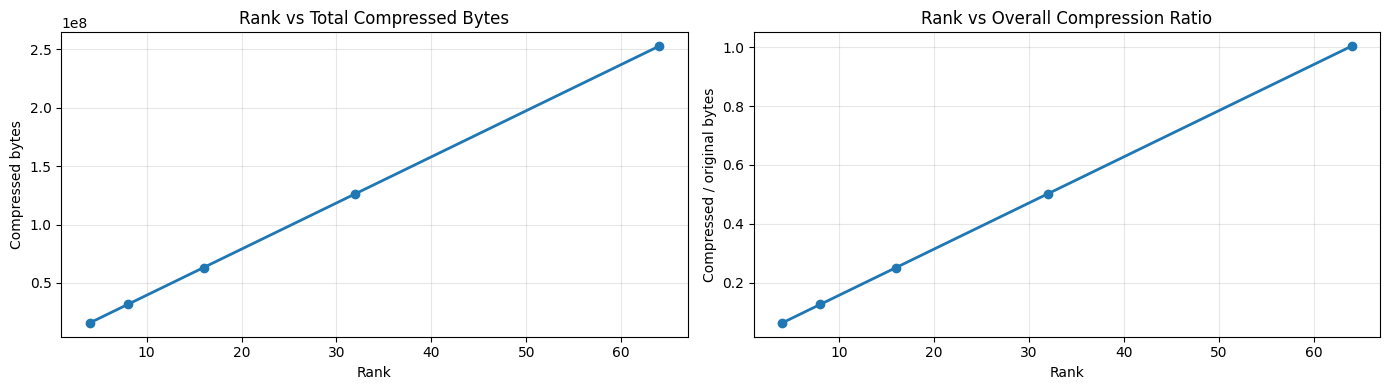

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(rank_overview["rank"], rank_overview["total_compressed_bytes"], marker="o", linewidth=2)
axes[0].set_title("Rank vs Total Compressed Bytes")
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Compressed bytes")
axes[0].grid(alpha=0.3)

axes[1].plot(rank_overview["rank"], rank_overview["overall_compression_ratio"], marker="o", linewidth=2)
axes[1].set_title("Rank vs Overall Compression Ratio")
axes[1].set_xlabel("Rank")
axes[1].set_ylabel("Compressed / original bytes")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
def load_rank_kl_percentiles(kl_run_dirs: dict[int, str | Path], percentiles=(50, 90, 99, 99.9)):
    rows = []
    for rank, run_dir in sorted(kl_run_dirs.items()):
        run_path = Path(run_dir)
        kl_arrays = []
        for kl_path in sorted(run_path.glob("*_kl.pt")):
            tensor = torch.load(kl_path, map_location="cpu")
            arr = tensor.detach().float().cpu().numpy().reshape(-1)
            if arr.size:
                kl_arrays.append(arr)
        if not kl_arrays:
            continue
        merged = np.concatenate(kl_arrays)
        row = {"rank": rank, "run_dir": str(run_path), "num_kl_values": int(merged.size)}
        for p in percentiles:
            label = "median" if p == 50 else f"p{p}"
            row[label] = float(np.percentile(merged, p))
        rows.append(row)
    return pd.DataFrame(rows)


kl_tradeoff_df = load_rank_kl_percentiles(KL_RUN_DIRS)
tradeoff_df = rank_overview.merge(kl_tradeoff_df, on="rank", how="inner")
tradeoff_df


,rank,steps_analyzed,unique_state_tensors,total_original_bytes,total_compressed_bytes,total_savings_bytes,overall_compression_ratio,overall_compression_percent,total_original,total_compressed,total_savings,run_dir,num_kl_values,median,p90,p99,p99.9
0,4,5,24,251658240,15790080,235868160,0.062744,93.725586,240.00 MB,15.06 MB,224.94 MB,state_spectrum_sweep/experiments/suite_kl_2026...,5985,2.746582e-04,0.031494,0.128242,0.281375
1,8,5,24,251658240,31580160,220078080,0.125488,87.451172,240.00 MB,30.12 MB,209.88 MB,state_spectrum_sweep/experiments/suite_kl_2026...,5969,5.722046e-05,0.010010,0.040850,0.093418
2,16,5,24,251658240,63160320,188497920,0.250977,74.902344,240.00 MB,60.23 MB,179.77 MB,state_spectrum_sweep/experiments/suite_kl_2026...,6000,4.291534e-06,0.003571,0.012208,0.025517
3,32,5,24,251658240,126320640,125337600,0.501953,49.804688,240.00 MB,120.47 MB,119.53 MB,state_spectrum_sweep/experiments/suite_kl_2026...,5984,3.650784e-07,0.001732,0.005951,0.008733
4,64,5,24,251658240,252641280,-983040,1.003906,-0.390625,240.00 MB,240.94 MB,-960.00 KB,state_spectrum_sweep/experiments/suite_kl_2026...,6000,1.667067e-07,0.001359,0.004791,0.007172


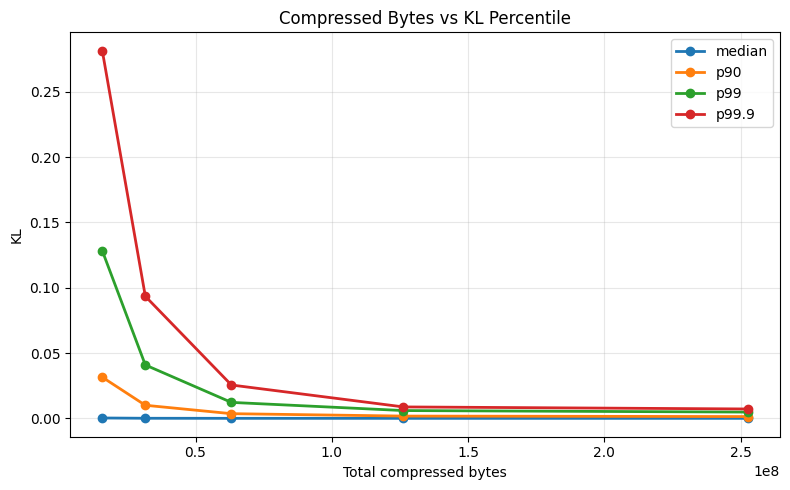

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
for label in ["median", "p90", "p99", "p99.9"]:
    if label in tradeoff_df.columns:
        ax.plot(tradeoff_df["total_compressed_bytes"], tradeoff_df[label], marker="o", linewidth=2, label=label)

ax.set_title("Compressed Bytes vs KL Percentile")
ax.set_xlabel("Total compressed bytes")
ax.set_ylabel("KL")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Notes

- This notebook is **Qwen-specific**, not Mamba-specific.
- It captures **Qwen recurrent-state tensors** from `Qwen3_5GatedDeltaNet` layers using the same cache-update path that worked in the experiment scripts.
- `rank_overview` is the main table for comparing `overall_compression_ratio` and `total_compressed_bytes` across ranks.
- `summary_by_kind` and `summary_by_layer` provide the rank-sliced breakdowns.
- `tradeoff_df` joins memory estimates with the existing KL runs from `KL_RUN_DIRS`.
- This notebook estimates **low-rank storage size**, not peak runtime GPU memory.
- `FACTOR_STORAGE = "float32"` is the conservative setting, since SVD factors are often stored in fp32 for stability.
